## Install Python Libraries

Start by running the following cell if needed to install required libraries:

In [1]:
!pip install datasets tokenizers

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_from_disk
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import os
from collections import Counter

from sklearn.metrics import confusion_matrix, classification_report
os.environ["TOKENIZERS_PARALLELISM"] = "false" # Avoids warning from tokenizer when using num_workers > 0 in DataLoader

SEED = 420

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Encoder-only Transformer for Text Sentiment Classification

## 1. Data

### 1.1 Load the IMDB dataset

We will use the IMDB dataset for sentiment classification. The dataset consists of 50,000 movie reviews, each labeled as positive or negative. We will use 25k reviews for training, 5k for validation, and 20k for testing.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# Constants
SEED = 420
VAL_SIZE = 0.2

# Load IMDB dataset
dataset_train = load_from_disk("imdb_train")
dataset_test = load_from_disk("imdb_test")

# Split test into test and validation
dataset_test = dataset_test.train_test_split(test_size=1-VAL_SIZE, seed=SEED)
dataset_test, dataset_val = dataset_test["test"], dataset_test["train"]

print(f"Train size: {len(dataset_train)}")
print(f"Validation size: {len(dataset_val)}")
print(f"Test size: {len(dataset_test)}")

Train size: 25000
Validation size: 5000
Test size: 20000


In [5]:
# Sanity checks before preprocessing

def summarize_split(name, dataset):
    print(f"\n{name} split")
    print(f"Size: {len(dataset)}")

    # Check expected fields
    expected_fields = {"text", "label"}
    actual_fields = set(dataset.column_names)
    print(f"Fields: {dataset.column_names}")
    assert expected_fields.issubset(actual_fields), (
        f"{name} is missing expected fields: {expected_fields - actual_fields}"
    )

    # Check class balance
    labels = dataset["label"]
    unique_labels = sorted(set(labels))
    print("Class distribution:")
    for label in unique_labels:
        count = labels.count(label)
        percentage = 100 * count / len(labels)
        print(f"  Label {label}: {count} samples ({percentage:.2f}%)")

# Check for missing or invalid values in text and label fields
def check_missing_and_invalid(name, dataset):
    missing_text = sum(x is None for x in dataset["text"])
    missing_label = sum(x is None for x in dataset["label"])
    non_string_text = sum(not isinstance(x, str) for x in dataset["text"])
    empty_text = sum(isinstance(x, str) and x.strip() == "" for x in dataset["text"])

    print(f"\n{name} missing/invalid value check")
    print(f"  Missing text: {missing_text}")
    print(f"  Missing label: {missing_label}")
    print(f"  Non-string text entries: {non_string_text}")
    print(f"  Empty/whitespace-only reviews: {empty_text}")

summarize_split("Train", dataset_train)
summarize_split("Validation", dataset_val)
summarize_split("Test", dataset_test)

check_missing_and_invalid("Train", dataset_train)
check_missing_and_invalid("Validation", dataset_val)
check_missing_and_invalid("Test", dataset_test)

# Print a few raw examples from the training set
print("\nExamples from the training set:")
print(f"\nExample {1}")
print(f"Label: {dataset_train[0]['label']}")
print(f"Review: {dataset_train[0]['text']}")

print(f"\nExample {25000}")
print(f"Label: {dataset_train[24999]['label']}")
print(f"Review: {dataset_train[24999]['text']}")




Train split
Size: 25000
Fields: ['text', 'label']
Class distribution:
  Label 0: 12500 samples (50.00%)
  Label 1: 12500 samples (50.00%)

Validation split
Size: 5000
Fields: ['text', 'label']
Class distribution:
  Label 0: 2513 samples (50.26%)
  Label 1: 2487 samples (49.74%)

Test split
Size: 20000
Fields: ['text', 'label']
Class distribution:
  Label 0: 9987 samples (49.94%)
  Label 1: 10013 samples (50.06%)

Train missing/invalid value check
  Missing text: 0
  Missing label: 0
  Non-string text entries: 0
  Empty/whitespace-only reviews: 0

Validation missing/invalid value check
  Missing text: 0
  Missing label: 0
  Non-string text entries: 0
  Empty/whitespace-only reviews: 0

Test missing/invalid value check
  Missing text: 0
  Missing label: 0
  Non-string text entries: 0
  Empty/whitespace-only reviews: 0

Examples from the training set:

Example 1
Label: 0
Review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was

### 1.2 Preprocess the data

We remove HTML tags, special characters, and convert the text to lowercase.

In [6]:
def remove_html_tags(text):
    # Remove HTML tags
    return re.sub(r'<[^>]*>', '', text)

def remove_special_characters(text):
    # Remove special characters except for ,.!? and space
    return re.sub(r'[^a-zA-Z0-9.,!? ]', '', text)

def to_lowercase(text):
    # Convert text to lowercase
    return text.lower()

def preprocess_text(text):
    # Apply all preprocessing steps to the text
    text = remove_html_tags(text)
    text = remove_special_characters(text)
    text = to_lowercase(text)
    return text

def preprocess_batch(examples):
    # Apply preprocessing to all texts in the batch
    examples["text"] = [preprocess_text(text) for text in examples["text"]]
    return examples

# Preprocess the dataset
dataset_train = dataset_train.map(preprocess_batch, batched=True)
dataset_val = dataset_val.map(preprocess_batch, batched=True)
dataset_test = dataset_test.map(preprocess_batch, batched=True)

### 1.3 Tokenization

We use a simple word-level tokenizer to tokenize the text data. We use three special tokens: `[PAD]`, `[UNK]` and `[CLS]`. The `[PAD]` token will be used to pad the input sequences to the same length. The `[UNK]` token is used to represent out-of-vocabulary words (rare words). When classifying text, we will prepend the `[CLS]` token to the input sequence and use its output as the representation of the whole sequence.

To reduce the vocabulary size, we only keep words appearing at least `MIN_FREQUENCY` times in the training set.

In [7]:
# Special tokens (padding, unknown, classification)
PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"
CLS_TOKEN = "[CLS]"
MIN_FREQUENCY = 10
VOCAB_SIZE = 10000

# Tokenizer setup
tokenizer = Tokenizer(WordLevel(unk_token=UNK_TOKEN))
tokenizer.pre_tokenizer = Whitespace() # Split on whitespace

# Train tokenizer on the training set
trainer = WordLevelTrainer(special_tokens=[PAD_TOKEN, UNK_TOKEN, CLS_TOKEN], min_frequency=MIN_FREQUENCY, vocab_size=VOCAB_SIZE)
tokenizer.train_from_iterator(dataset_train["text"], trainer)

In [8]:
# Check which integer a specific word maps to
print(tokenizer.token_to_id("movie"))
print(tokenizer.token_to_id("great"))
print(tokenizer.token_to_id("bad"))

20
90
84


We test the tokenizer on a few examples to verify that it works as expected.

In [9]:
for idx in range(5):
    example = dataset_train[idx]
    original_text = example["text"]
    tokenized_text = tokenizer.encode(example["text"])
    decoded_text = tokenizer.decode(tokenized_text.ids, skip_special_tokens=False)

    print(f"Original text: {original_text}")
    print(f"Tokenized text (tokens): {tokenized_text.tokens}")
    print(f"Tokenized text (IDs): {tokenized_text.ids}")
    print(f"Decoded text: {decoded_text}")
    print()

Original text: i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered controversial i really had to see this for myself.the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life. in particular she wants to focus her attentions to making some sort of documentary on what the average swede thought about certain political issues such as the vietnam war and race issues in the united states. in between asking politicians and ordinary denizens of stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.what kills me about i am curiousyellow is that 40 years ago, this was considered pornographic. really, the sex and nudity scenes are few and far between, even then its no

We plot the distribution of the sequence lengths in the training set. Later, we can use this to determine the maximum sequence length to use.

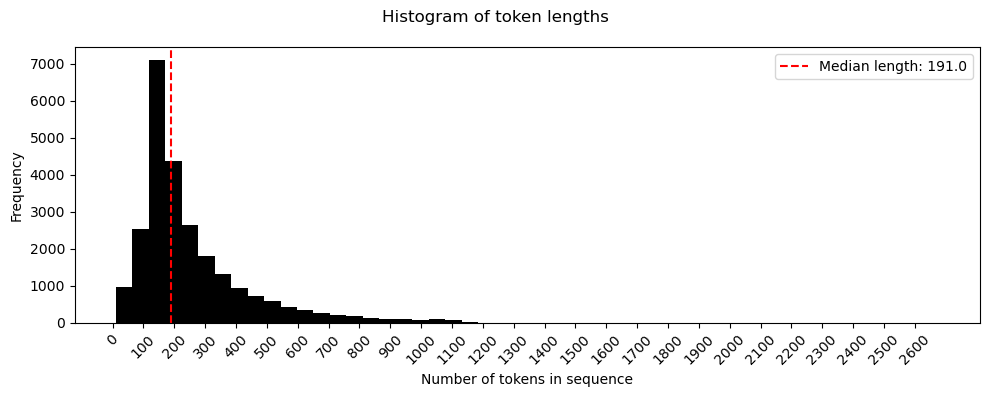

In [10]:
# Histogram of token lengths
token_lengths = [len(tokenizer.encode(text).ids) for text in dataset_train["text"]]
median_length = np.median(token_lengths)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=50, color="black")
ax.set_xticks(np.arange(0, np.max(token_lengths) + 1, 100))
ax.tick_params(axis="x", labelrotation=45)
ax.set_xlabel("Number of tokens in sequence")
ax.set_ylabel("Frequency")
ax.axvline(median_length, color="red", linestyle="--", label=f"Median length: {median_length}")
ax.legend()
fig.suptitle("Histogram of token lengths")
fig.tight_layout()
plt.show()

In [11]:
# -----------------------------------------------------------------

# Count token frequencies on the training set
token_counter = Counter()

for text in dataset_train["text"]:
    encoding = tokenizer.encode(text)
    token_counter.update(encoding.tokens)

# Remove special tokens if present
for special_token in [PAD_TOKEN, UNK_TOKEN, CLS_TOKEN]:
    token_counter.pop(special_token, None)


# -----------------------------------------------------------------


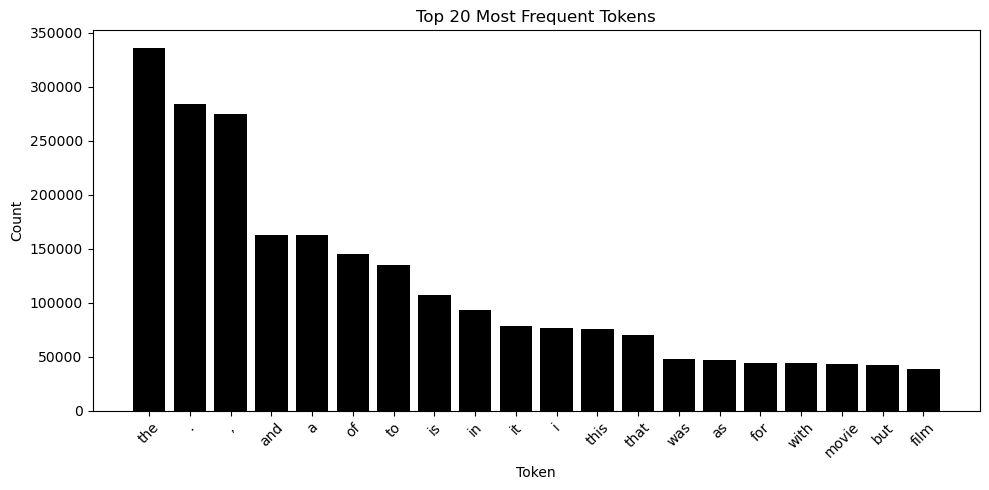

In [12]:
# Plot the most frequent tokens
top_k = 20
most_common = token_counter.most_common(top_k)

tokens = [token for token, count in most_common]
counts = [count for token, count in most_common]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(tokens, counts, color="black")
ax.set_xlabel("Token")
ax.set_ylabel("Count")
ax.set_title(f"Top {top_k} Most Frequent Tokens")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


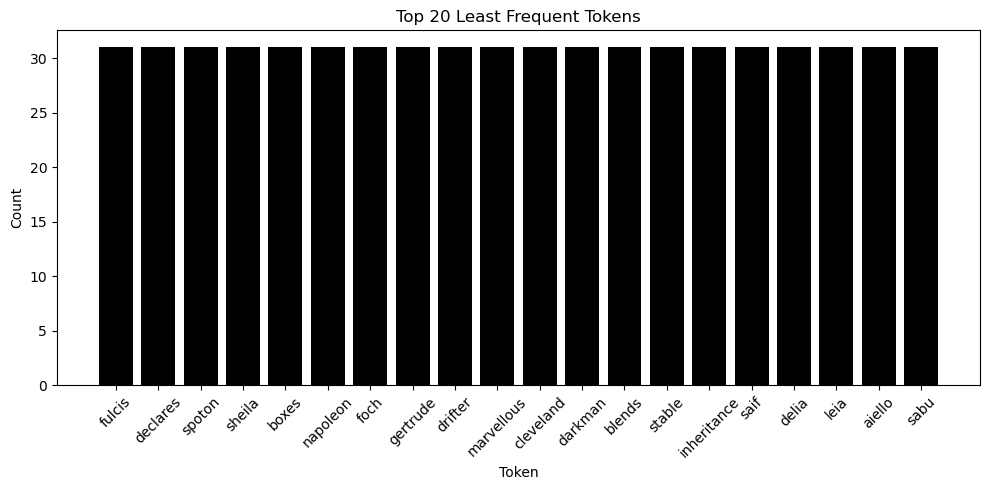

In [13]:
# Plot the least frequent tokens
low_k = 20
least_common = token_counter.most_common()[-low_k:]

tokens = [token for token, count in least_common]
counts = [count for token, count in least_common]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(tokens, counts, color="black")
ax.set_xlabel("Token")
ax.set_ylabel("Count")
ax.set_title(f"Top {low_k} Least Frequent Tokens")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

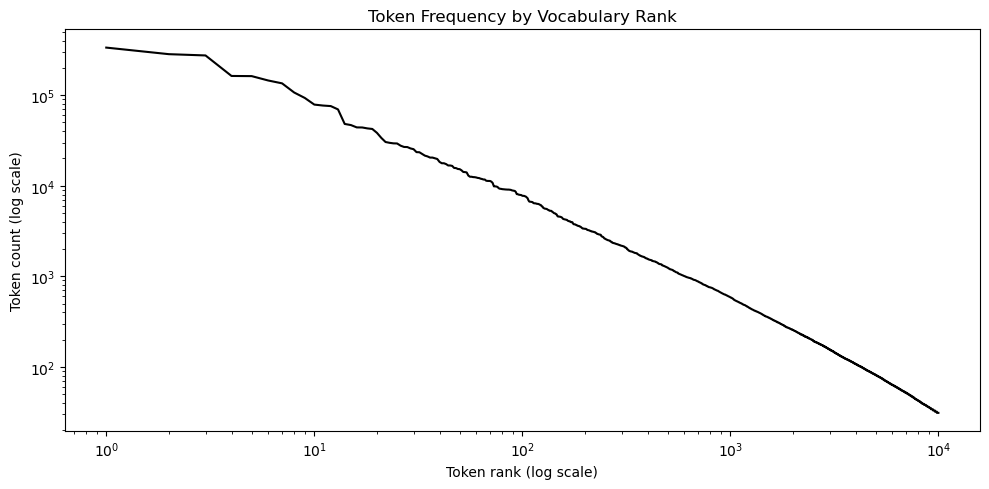

In [14]:
# Plot token frequency by vocabulary rank (Zipf-like plot)
sorted_counts = sorted(token_counter.values(), reverse=True)
ranks = np.arange(1, len(sorted_counts) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ranks, sorted_counts, color="black")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Token rank (log scale)")
ax.set_ylabel("Token count (log scale)")
ax.set_title("Token Frequency by Vocabulary Rank")
fig.tight_layout()
plt.show()


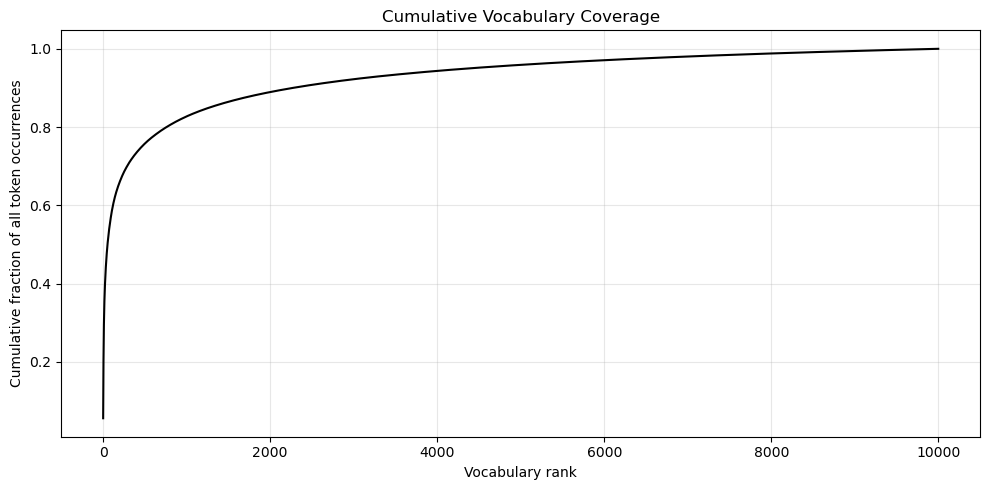

In [15]:
# Plot cumulative token coverage
cumulative_counts = np.cumsum(sorted_counts)
cumulative_coverage = cumulative_counts / cumulative_counts[-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ranks, cumulative_coverage, color="black")
ax.set_xlabel("Vocabulary rank")
ax.set_ylabel("Cumulative fraction of all token occurrences")
ax.set_title("Cumulative Vocabulary Coverage")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


[np.float64(0.96188), np.float64(0.81628), np.float64(0.33384), np.float64(0.09416)]


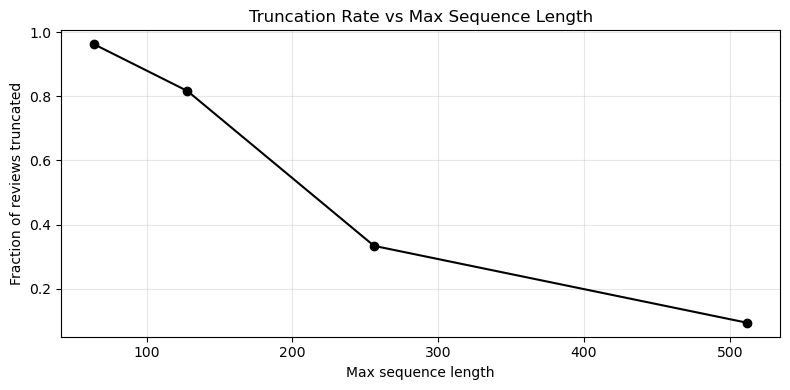

In [16]:
# Fraction of reviews that would be truncated for different max lengths
candidate_lengths = [64, 128, 256, 512]
truncation_rates = [
    np.mean(np.array(token_lengths) > max_len) for max_len in candidate_lengths
]

print(truncation_rates)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(candidate_lengths, truncation_rates, marker="o", color="black")
ax.set_xlabel("Max sequence length")
ax.set_ylabel("Fraction of reviews truncated")
ax.set_title("Truncation Rate vs Max Sequence Length")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


### 1.4 Dataset and Data Loaders

To deal with sequences of different lengths, we implement a simple `IMDBDataset` class that pads the sequences to the same length using the `[PAD]` token, or truncates them if they exceed the maximum sequence length. We also prepend the `[CLS]` token to the input sequences.

In [17]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length, pad_idx, cls_idx):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.cls_idx = cls_idx
    
    def __len__(self):
        return len(self.texts)
    
    # IMPLEMENTATION HERE
    def __getitem__(self, idx):
        text = self.texts[idx] # Retrieve the text
        label = self.labels[idx] # And label

        token_ids = self.tokenizer.encode(text).ids # Tokenize the review and get ID
        token_ids = [self.cls_idx] + token_ids # Add cls token
        token_ids = token_ids[:self.max_length] # Truncate if too long

        padding_length = self.max_length - len(token_ids) # Calculate padding lenght
        token_ids = token_ids + [self.pad_idx] * padding_length # Pad sequence

        sequence = torch.tensor(token_ids, dtype=torch.long) # Convert to tensor
        label = torch.tensor(label, dtype=torch.float32)

        return sequence, label


We create some constants:

- `MAX_LENGTH`: the maximum sequence length
- `PAD_ID`: the ID of the `[PAD]` token
- `CLS_ID`: the ID of the `[CLS]` token
- `BATCH_SIZE`: the batch size
- `NUM_WORKERS`: the number of workers for data loading (set this to 0 if you are encountering issues with the DataLoader)

We also create the training and testing datasets and data loaders.

In [18]:
# Constants
MAX_LENGTH = 256
PAD_ID = tokenizer.token_to_id(PAD_TOKEN)
CLS_ID = tokenizer.token_to_id(CLS_TOKEN)
BATCH_SIZE = 64
NUM_WORKERS = 4

# Dataset instances
train_dataset = IMDBDataset(dataset_train["text"], dataset_train["label"], tokenizer, MAX_LENGTH, PAD_ID, CLS_ID)
val_dataset = IMDBDataset(dataset_val["text"], dataset_val["label"], tokenizer, MAX_LENGTH, PAD_ID, CLS_ID)
test_dataset = IMDBDataset(dataset_test["text"], dataset_test["label"], tokenizer, MAX_LENGTH, PAD_ID, CLS_ID)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

## 2. Model

### 2.1 Training Loop

We define a simple train function that takes `model` and trains it for `num_epochs` on `train_loader`. We give the `criterion` (loss function) and `optimizer` as arguments to the function. The train function also needs to know `pad_id`, the ID of the `[PAD]` token so we can generate the attention mask making sure the model does not attend to the padding tokens. After each epoch, we evaluate the model on `val_loader`.

In [19]:
def create_mask(sequences, pad_id):
    """
    Input shape of token sequences: (batch_size, seq_length)
    Output shape: (batch_size, seq_length) boolean mask with True where the padding tokens are located
    """
    # creates a boolean mask
    return sequences == pad_id

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, pad_id, device):
    train_loss_history = []   # For plotting
    val_loss_history = [] 
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        correct, total = 0, 0

        for sequences, labels in (pbar := tqdm(train_loader)):
            sequences = sequences.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            attention_mask = create_mask(sequences, pad_id).to(device)

            outputs = model(sequences, mask=attention_mask)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

            train_losses.append(loss.item())
            correct += ((outputs > 0.5) == labels).sum().item()
            total += labels.size(0)
            pbar.set_description(
                f"Epoch {epoch+1}, Train Loss: {np.mean(train_losses):.4f}, Train Acc.: {correct / total:.4f}"
            )

        train_loss_history.append(np.mean(train_losses))
        
        model.eval()
        val_losses = []
        correct, total = 0, 0

        with torch.no_grad():
            for sequences, labels in tqdm(val_loader):
                sequences = sequences.to(device)
                labels = labels.float().to(device)
                attention_mask = create_mask(sequences, pad_id).to(device)

                outputs = model(sequences, mask=attention_mask)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item())
                correct += ((outputs > 0.5) == labels).sum().item()
                total += labels.size(0)

        val_loss_history.append(np.mean(val_losses))
        print(f"Epoch {epoch+1}, Val Loss: {np.mean(val_losses):.4f}, Val Acc.: {correct / total:.4f}")

    return train_loss_history, val_loss_history
    


### 2.2 Multi-Head Attention

We implement the multi-head attention mechanism. The multi-head attention mechanism consists of `num_heads` independent attention mechanisms. We concatenate the outputs of the different heads and project them back to the model's dimension. We use the scaled dot-product attention mechanism.

In [20]:
class MultiheadAttention(nn.Module):
    def __init__(self, dim, num_heads):
        """
        Multihead attention module.
        Args:
            dim: Dimension of the input vectors
            num_heads: Number of attention heads
            dropout: Dropout rate for attention scores (default: 0.1)
        """
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads

        assert dim % num_heads == 0, f"Dimension {dim} must be divisible by num_heads {num_heads}"

        self.head_dim = dim // num_heads

        # Linear transformations for query, key, and value
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)

        # Output linear transformation
        self.out_proj = nn.Linear(dim, dim)

    def forward(self, query, key, value, key_padding_mask):
        batch_size, query_len, _ = query.shape
        key_len = key.shape[1]

        # Reshape and transpose for multi-head attention
        # From (batch_size, seq_length, dim) to (batch_size, num_heads, seq_length, head_dim)
        q = self.query(query).view(batch_size, query_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key(key).view(batch_size, key_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value(value).view(batch_size, key_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Compute scaled dot-product attention
        attention_scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.head_dim)
        # If key_padding_mask is not None, mask out the padding tokens by setting their attention scores to -inf
        if key_padding_mask is not None:
            attention_scores = attention_scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2),
                float("-inf")
            )

        # Convert attention scores to probabilities and compute weighted sum of values
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_weights, v)

        # Reshape back to original dimensions
        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, query_len, self.dim)

        # Final output
        return self.out_proj(attention_output)


### 2.3 Encoder Block

We implement the encoder block, which consists of our multi-head attention layer followed by a feedforward neural network. We also add residual connections and layer normalizations as specified in the project description.

In [21]:
class EncoderBlock(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiheadAttention(dim, num_heads) # Multi-head attention
        self.norm1 = nn.LayerNorm(dim) # Layer normalization after attention
        self.norm2 = nn.LayerNorm(dim) # layer normalization after feedforward
        self.dropout = nn.Dropout(dropout) # Dropout layer for regularizatio
        # Positiional wise feedforward network
        self.feedforward = nn.Sequential( 
            nn.Linear(dim, 4 * dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dim, dim),
        )

    def forward(self, x, mask=None): 
        attention_output = self.attention(x, x, x, mask) # Apply self-attention
        x = self.norm1(x + self.dropout(attention_output)) # ADD residual connection and layer normalization and dropout

        feedforward_output = self.feedforward(x) # Pass through feedforward network
        x = self.norm2(x + self.dropout(feedforward_output)) # Add another residual connecton, dropout, and layer normalization

        return x


### 2.4 Model Specification

We specify our classifier model, which consists of an embedding layer, followed by `num_layers` encoder blocks. We use a linear layer to project the output of the last encoder block and apply sigmoid activation to get the final output.

We also define the positional encoding, which is added to the input embeddings to give the model information about the position of the tokens in the sequence.

In [22]:
class PositionalEncoding(nn.Module):
    """
    Positional encoding module: adds positional information to the input embeddings.
    """
    def __init__(self, embed_size, max_len):
        super().__init__()

        # Create vector 
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        # Determine the frequencies for each dimension of the positional encoding
        div_term = torch.exp(
            torch.arange(0, embed_size, 2, dtype=torch.float32) * (-np.log(10000.0) / embed_size)
        )
         # Initialize matrix for positiional encoding
        positional_encoding = torch.zeros(max_len, embed_size)
        # Apply sine to even dimensions and cosine to odd dimensions
        positional_encoding[:, 0::2] = torch.sin(position * div_term)
        positional_encoding[:, 1::2] = torch.cos(position * div_term)

        # Store the positiional encoding as buffer
        self.register_buffer("positional_encoding", positional_encoding.unsqueeze(0))

    # Add positional encoding to input embeddings
    def forward(self, x):
        return x + self.positional_encoding[:, :x.size(1), :].to(x.device)

class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, embedding_dim, num_heads, num_layers, pad_idx, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(embedding_dim, max_len)
        
        self.encoder = nn.ModuleList([EncoderBlock(embedding_dim, num_heads, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(embedding_dim, 1)  # Output layer
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x, mask=None):
        x = self.embedding(x)  # Shape: (batch_size, seq_len, embedding_dim)
        x = self.pos_encoder(x)  # Add positional encodings

        for encoder in self.encoder:
            x = encoder(x, mask=mask)

        x = x[:, 0, :]  # Take the first token's embedding (CLS token equivalent)

        return self.sigmoid(self.fc(x)).squeeze()


### 2.5 Training the Model

We can now train the model. It is recommended that you use the parameters provided in the cell below as they should work pretty good without requiring too much computational power.

Train the model for (at least) 3 epochs. Each epoch should take around 7 to 12 minutes on a modern CPU. If you are training on a laptop, make sure it is plugged in. Moreover, closing all other applications can also help. Take a well-deserved break while the model trains.

If you struggle with extremely long training times, you can do one or more of the following to speed up training:

- Increase `MIN_FREQUENCY` and re-train the tokenizer to reduce the vocabulary size.
- Use a subset of the training data.
- Reduce the number of epochs.
- Reduce the maximum sequence length.
- Experiment with `NUM_WORKERS` in the data loaders (optimal value is system-dependent).
- If you have a GPU, modify the training function above to use it.

Expect to observe a training accuracy above `0.60` halfway through the first epoch.

In [23]:
NUM_EPOCHS = 3
LR = 1e-3
WEIGHT_DECAY = 1e-3
EMBEDDING_DIM = 96
NUM_HEADS = 4
NUM_LAYERS = 3

model = SentimentTransformer(vocab_size=VOCAB_SIZE, 
                             max_len=MAX_LENGTH,
                             embedding_dim=EMBEDDING_DIM, 
                             num_heads=NUM_HEADS, 
                             num_layers=NUM_LAYERS, 
                             pad_idx=PAD_ID).to(device)

criterion = nn.BCELoss() # Model output should have sigmoid applied!
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

train_losses, val_losses = train_model(model=model,
                                            criterion=criterion,
                                            optimizer=optimizer,
                                            train_loader=train_loader,
                                            val_loader=val_loader,
                                            num_epochs=NUM_EPOCHS,
                                            pad_id=PAD_ID,
                                           device=device)

Number of parameters: 1295617


100%|██████████| 79/79 [00:02<00:00, 28.22it/s]


Epoch 1, Val Loss: 0.4227, Val Acc.: 0.8084


100%|██████████| 79/79 [00:02<00:00, 28.32it/s]


Epoch 2, Val Loss: 0.3758, Val Acc.: 0.8370


100%|██████████| 79/79 [00:02<00:00, 27.30it/s]

Epoch 3, Val Loss: 0.3531, Val Acc.: 0.8538


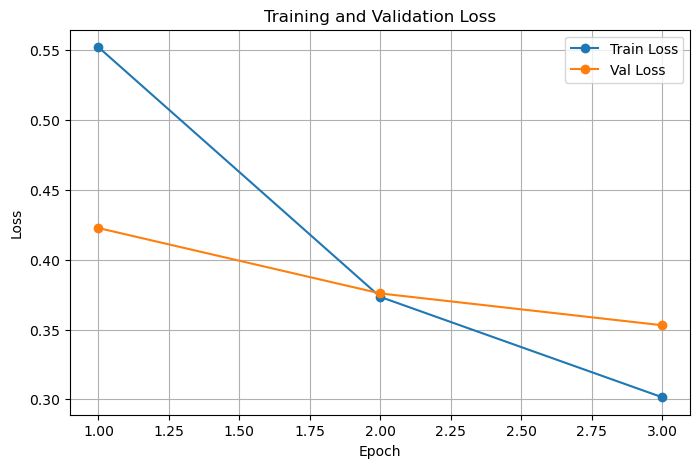

In [24]:
# Plot training and validatio loss curves

plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### 2.6 Evaluating the Model on Unseen Data

We evaluate the model on the test set and print the test accuracy.

100%|██████████| 313/313 [00:11<00:00, 26.96it/s]


Accuracy (test): 0.8488

Classification report:
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      9987
    positive       0.85      0.85      0.85     10013

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



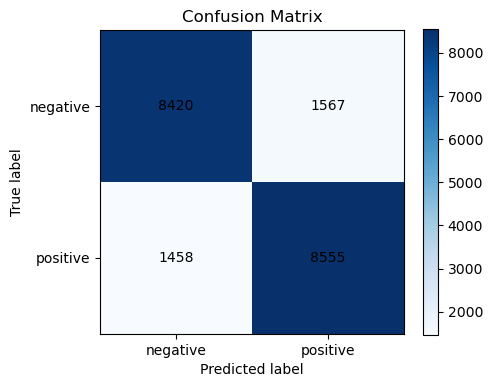

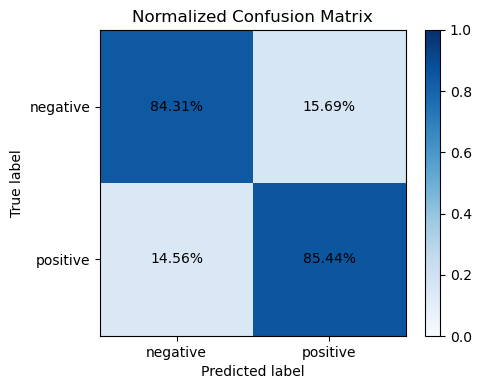

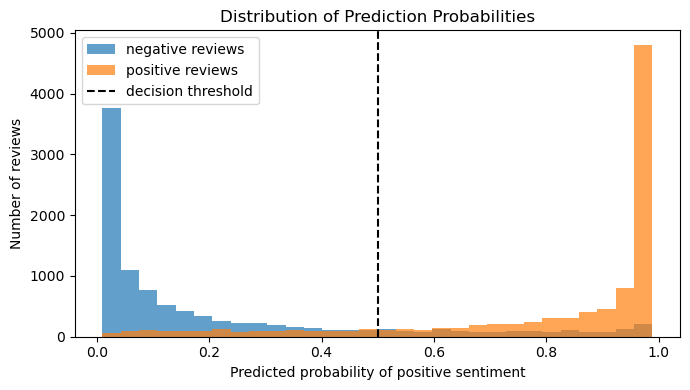


Showing 10 failed reviews:

Failed review #1
True label:      negative
Predicted label: positive
Model output:    0.9871
Review:
based on the comments made so far , everyone seems to either hate this movie or love it . i think it would be fair to point out that although this is not a great movie , it has its interesting moments . for one thing , it was filmed on location in was it or ? i cant remember , but it is in the credits . the location is absolutely stunning and spectacular . its beautiful , even to me who lived in for several years . next , it has disneys for wonderful character actors . harry morgan has never been in better form than when he plays in a disney movie . he is literally hysterical . also , remember the wonderful mary ? although she has a bit part in this movie , she is great , as always . if you dont know who she is , think of the animated disney version of from dame she was one of the , and she was also the most interesting nun in sister act , as well as the bes

In [25]:
def decode_review(sequence, tokenizer, pad_id):
    token_ids = sequence.detach().cpu().tolist()

    # Remove padding tokens
    token_ids = [token_id for token_id in token_ids if token_id != pad_id]
    
    # Convert back to text to investigate possible failed reviews
    return tokenizer.decode(token_ids, skip_special_tokens=True)


def evaluate_model_with_confusion_matrix(
    model,
    test_loader,
    pad_id,
    device,
    tokenizer,
    num_failed_reviews=5
):
    model.eval() # Evaluation mode
    correct, total = 0, 0 # Counter for accuracy calculation

    all_labels = [] # List to store labels, predictions, and model outputs for all test samples
    all_predictions = []
    all_outputs = []
    failed_reviews = []

    with torch.no_grad():
        # Iterate through the test set and make predictions
        for sequences, labels in tqdm(test_loader):
            sequences = sequences.to(device)
            labels = labels.to(device)

            attention_mask = create_mask(sequences, pad_id).to(device)

            outputs = model(sequences, mask=attention_mask) # Run model on the input sequences to get predicted probabilities
            predictions = (outputs > 0.5).float() # Convert probabilities to binary predictions using 0.5 threshold

            correct += (predictions == labels).sum().item() # Update the count of correct predictions and total samples for accuracy calculation
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy().astype(int)) # Store true labels, predicted labels, and model outputs for later 
            all_predictions.extend(predictions.cpu().numpy().astype(int))
            all_outputs.extend(outputs.cpu().numpy())

            incorrect_mask = predictions != labels # Identify misclassified samples in the batch

            for i in range(labels.size(0)): # Decode for qualitiative inspection of failed reviews
                if incorrect_mask[i].item():
                    failed_reviews.append({
                        "review": decode_review(sequences[i], tokenizer, pad_id),
                        "true_label": int(labels[i].item()),
                        "predicted_label": int(predictions[i].item()),
                        "model_output": float(outputs[i].item())
                    })

    accuracy = correct / total #    Calculate overall accuracy on the test set

    print(f"Accuracy (test): {accuracy:.4f}")

    print("\nClassification report:")
    print(classification_report(
        all_labels,
        all_predictions,
        target_names=["negative", "positive"]
    ))

    all_labels = np.array(all_labels).astype(int).flatten() # For confusion matrix, and plotting, to numpy arrays
    all_predictions = np.array(all_predictions).astype(int).flatten()
    all_outputs = np.array(all_outputs).flatten()

    cm = confusion_matrix(all_labels, all_predictions) # Compute confusion matrix

    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True) # Normalize confusion matrix

    # Plot unnormalized confusion matrix
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["negative", "positive"])
    plt.yticks([0, 1], ["negative", "positive"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="black"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Plot normalized confusion matrix
    plt.figure(figsize=(5, 4))
    plt.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["negative", "positive"])
    plt.yticks([0, 1], ["negative", "positive"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                f"{cm_normalized[i, j]:.2%}",
                ha="center",
                va="center",
                color="black"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Plot distribution of prediction probabilities
    plt.figure(figsize=(7, 4))
    plt.hist(
        all_outputs[all_labels == 0],
        bins=30,
        alpha=0.7,
        label="negative reviews",
        color="tab:blue"
    )
    plt.hist(
        all_outputs[all_labels == 1],
        bins=30,
        alpha=0.7,
        label="positive reviews",
        color="tab:orange"
    )
    plt.axvline(
        0.5,
        color="black",
        linestyle="--",
        label="decision threshold"
    )
    plt.xlabel("Predicted probability of positive sentiment")
    plt.ylabel("Number of reviews")
    plt.title("Distribution of Prediction Probabilities")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print a limited number of misclassified reviews for qualitative analysis.
    print(f"\nShowing {min(num_failed_reviews, len(failed_reviews))} failed reviews:")
    print("=" * 80)

    for idx, example in enumerate(failed_reviews[:num_failed_reviews], start=1):
        true_label = "positive" if example["true_label"] == 1 else "negative"
        predicted_label = "positive" if example["predicted_label"] == 1 else "negative"

        print(f"\nFailed review #{idx}")
        print(f"True label:      {true_label}")
        print(f"Predicted label: {predicted_label}")
        print(f"Model output:    {example['model_output']:.4f}")
        print("Review:")
        print(example["review"])
        print("-" * 80)

    return accuracy, cm, cm_normalized, failed_reviews, all_outputs

accuracy, cm, cm_normalized, failed_reviews, all_outputs = evaluate_model_with_confusion_matrix(
    model=model,
    test_loader=test_loader,
    pad_id=PAD_ID,
    device=device,
    tokenizer=tokenizer,
    num_failed_reviews=10
)

### 2.7 Testing the Model on Custom Examples

For fun, we test the model on some custom examples from IMDb.

In [26]:
# Function to classify a single review
def classify_review(review, model, tokenizer, pad_idx, cls_idx, max_length, device):
    model.eval()

    review = preprocess_text(review)
    token_ids = tokenizer.encode(review).ids
    token_ids = [cls_idx] + token_ids
    token_ids = token_ids[:max_length]
    token_ids = token_ids + [pad_idx] * (max_length - len(token_ids))

    sequence = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)
    attention_mask = create_mask(sequence, pad_idx).to(device)

    with torch.no_grad():
        p = model(sequence, mask=attention_mask).item()

    sentiment = "positive" if p > 0.5 else "negative"
    return sentiment, p


In [27]:
# External reviews to classify

reviews = [
    """From the prestige Asylum Films comes another one of their films with a bad premise 
    and laughably simplistic characters with no depth. The difference? This film is so bad that 
    it becomes entertaining to watch.

    As a hurricane picks up sharks from the Pacific Ocean, it continues to head for California. 
    There, a small band of survivors must try and escape and find the leader of the group's son in 
    all of the chaos.

    Using bad effects and cuts to actual sharks captured on film by other people, the sharks are jokes 
    in this film and takes away and tension that they might bring. But whatever, it is funny to watch a 
    bunch of sharks being tossed through windows and into streets to eat people.

    There is a lot of setup with no pay off or things that just sort of happen. One of the characters 
    (Cassie Scerbo) is in love with the main character but instead is with his son in the end without 
    any explanation which just comes across as random.

    While extremely corny and bad, you can enjoy laughing at the awful animated sharks, the bad dialog 
    and characters, and the strange ideas that the characters have during the course of the film.""",

    """10/10 for my friend Chicken Joe he was stoned af the whole movie""",

    """I recently saw The Bridge on the River Kwai at the Cinerama Dome, and it was quite spectacular. 
    Unlike some of today's grand adventure films, you get to know the characters along with seeing great 
    scenes of acting and cinematography. Alec Guinness is at the top of his form as the single minded 
    Colonel Nicholson. The scene between Nicholson and Saito in Saito's hut is remarkable. Nicholson 
    still will not concede defeat, he even takes offense that other officers of different armies gave 
    in and worked alongside the enlisted men. Saito can't understand Nicholson's acceptance of his 
    punishment, and it drives him crazy. The film's plot has two stories that are beautifully intertwined. 
    Shears' return to the bridge is his only way to escape the bridge. In the film's final act, the tension 
    is turned up as the British commandos try to blow up the bridge, and a train, and only then does 
    Nicholson realise what the bridge really is. The Bridge on the River Kwai is one film that is hard to 
    top, the only film able to do that is Lawrence of Arabia, both directed by the meticulous eye 
    of David Lean. One director who could put intimacy in epic circumstances.""",

    """Like the child -- and adults -- in the film, the audience is blind to the simple, shattering reality: 
    Amelia created the Babadook. Amelia is -- and always was -- the Babadook. The film brilliantly depicts 
    the dissociated perceptions of both child and mother as they attempt to survive their horrifying and 
    tragic reality. Because, who can fathom a mother who is pathologically detached, hateful, malicious, 
    and... violent towards her child? Not the child, not the mother, and not even the adults that surround 
    them. The adults who watch this film. We are blinded by our deeply held belief that mothers are supposed 
    to be nurturing, loving, and most of all... safe havens for their children. The reality is that Amelia 
    is possessed -- by borderline personality disorder triggered by the traumatic loss of her husband. 
    A perpetual victim, she feeds off of her self-pity and the pity of those around her, using it to 
    justify her seething resentment of her child. Unable to take responsibility for her abusive behavior, 
    she birthed the "Babadook". Underneath it all is a deeply troubled mother -- and a brave child living 
    in constant fear of and for his mother, desperately struggling to protect himself, protect his (abusive)
    mother, and, ultimately, to survive. I am so grateful for this film, which so perfectly encapsulates the 
    reality of hidden mental illness, giving life to the complex experiences of mother, child, and outside 
    observer"""
]

for i, review in enumerate(reviews, 1):
    sentiment, p = classify_review(review, model, tokenizer, PAD_ID, CLS_ID, MAX_LENGTH, device)
    print(f"Review {i}")
    print(f"Predicted sentiment: {sentiment} (p={p:.4f})")
    print()


Review 1
Predicted sentiment: negative (p=0.0332)

Review 2
Predicted sentiment: positive (p=0.9224)

Review 3
Predicted sentiment: positive (p=0.9194)

Review 4
Predicted sentiment: positive (p=0.8614)

